# Decision Tree (Agrupado por Color) — XAI Analysis


**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** Decision Tree  

**Task:** Predict Pokémon **color group** (6 classes) from sprite color features (42 features)

**Novedad:** En lugar de predecir los 18 tipos originales, predecimos 6 "supertipos" basados en similitud cromática:
- Azul/Agua (water, ice, psychic)
- Rojo/Fuego (fire, fighting)
- Verde/Natural (grass, bug, ground)
- Gris/Metal (steel, rock, normal)
- Púrpura/Oscuro (ghost, poison, dark, dragon)
- Amarillo/Energía (electric, fairy)

## 0. Setup y Preprocesamiento con Agrupación

In [1]:
import sys
import warnings
from pathlib import Path

# Configure path to find src/common.py
_src_path = Path.cwd().parent / "src"
if str(_src_path) not in sys.path:
    sys.path.insert(0, str(_src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import shap
import lime
import lime.lime_tabular
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report

warnings.filterwarnings("ignore")

import common
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# DEFINIR MAPEO DE TIPOS → SUPERTIPOS (ESTRATEGIA 2)
TYPE_GROUPING = {
    # Azul/Agua
    "water": "blue_water",
    "ice": "blue_water",
    "psychic": "blue_water",
    
    # Rojo/Fuego
    "fire": "red_fire",
    "fighting": "red_fire",
    
    # Verde/Natural
    "grass": "green_nature",
    "bug": "green_nature",
    "ground": "green_nature",
    
    # Gris/Metal
    "steel": "gray_metal",
    "rock": "gray_metal",
    "normal": "gray_metal",
    
    # Púrpura/Oscuro
    "ghost": "purple_dark",
    "poison": "purple_dark",
    "dark": "purple_dark",
    "dragon": "purple_dark",
    
    # Amarillo/Energía
    "electric": "yellow_energy",
    "fairy": "yellow_energy",
    
    # Flying → excluir (estrategia anterior)
    "flying": None,
}

# Colores para visualización
GROUP_COLORS = {
    "blue_water": "#6890F0",
    "red_fire": "#F08030",
    "green_nature": "#78C850",
    "gray_metal": "#B8B8D0",
    "purple_dark": "#A040A0",
    "yellow_energy": "#F8D030",
}

print("✓ Mapeo de tipos definido")
print(f"  - 18 tipos → 6 supertipos")
print(f"  - Colores: {', '.join(GROUP_COLORS.keys())}")

✓ Mapeo de tipos definido
  - 18 tipos → 6 supertipos
  - Colores: blue_water, red_fire, green_nature, gray_metal, purple_dark, yellow_energy


In [3]:
# CARGAR DATOS Y APLICAR AGRUPACIÓN
# Usar common.load_data() pero ignorar la reclasificación de flying
csv_path = Path.cwd().parent / "data" / "processed" / "features.csv"
df = pd.read_csv(csv_path)

# SIMPLEMENTE: eliminar flying + mapear a supertipos
df = df[df["type1"] != "flying"].reset_index(drop=True)

# Mapear tipo1 a grupo
df["type_group"] = df["type1"].map(TYPE_GROUPING)
df = df[df["type_group"].notna()].reset_index(drop=True)  # Eliminar NaN si la hubiera

# Crear mapeo entero
unique_groups = sorted(df["type_group"].unique())
group_to_int = {g: i for i, g in enumerate(unique_groups)}
int_to_group = {i: g for g, i in group_to_int.items()}

df["type_group_encoded"] = df["type_group"].map(group_to_int)

# Feature columns
feature_cols = common.FEATURE_COLS_ALL

print(f"Dataset preparado:")
print(f"  - Shape: {df.shape}")
print(f"  - Tipos descartados: flying")
print(f"  - Grupos: {len(unique_groups)}")
print(f"  - Features: {len(feature_cols)}")
print(f"\nDistribución de grupos:")
print(df["type_group"].value_counts().sort_index())

Dataset preparado:
  - Shape: (1016, 49)
  - Tipos descartados: flying
  - Grupos: 6
  - Features: 42

Distribución de grupos:
type_group
blue_water       225
gray_metal       212
green_nature     226
purple_dark      159
red_fire         106
yellow_energy     88
Name: count, dtype: int64


# 1. Dataset Split & Scaling

In [4]:
# Train/test split
X = df[feature_cols].copy()
y = df["type_group_encoded"].copy()

X_train, X_test, y_train, y_test, train_idx, test_idx = [], [], [], [], [], []

# Usar stratified split
from sklearn.model_selection import train_test_split as sklearn_train_test_split
indices = np.arange(len(df))
X_train, X_test, y_train, y_test, train_idx, test_idx = sklearn_train_test_split(
    X, y, indices, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=feature_cols, 
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

# Class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight(
    "balanced", 
    classes=np.unique(y_train), 
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights_array))

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Classes: {y_train.nunique()}")
print(f"\nClass distribution (train):")
for gid in sorted(np.unique(y_train)):
    count = (y_train == gid).sum()
    group_name = int_to_group[gid]
    print(f"  {group_name}: {count}")

Train size: 812 | Test size: 204
Classes: 6

Class distribution (train):
  blue_water: 180
  gray_metal: 169
  green_nature: 181
  purple_dark: 127
  red_fire: 85
  yellow_energy: 70


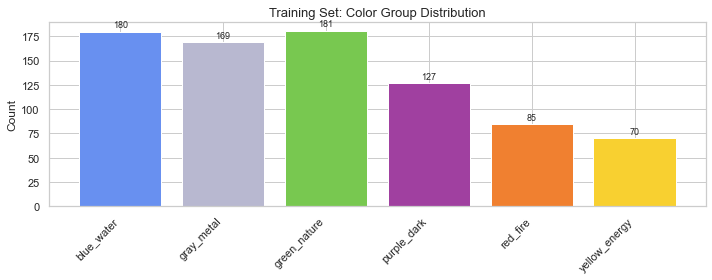

In [5]:
# Visualizar distribución
dist = y_train.value_counts().sort_index()
group_names = [int_to_group[i] for i in dist.index]
colors = [GROUP_COLORS.get(g, "#888888") for g in group_names]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(dist)), dist.values, color=colors, edgecolor="white", linewidth=1)
ax.set_xticks(range(len(dist)))
ax.set_xticklabels(group_names, rotation=45, ha="right")
ax.set_title("Training Set: Color Group Distribution", fontsize=13)
ax.set_ylabel("Count")

for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# 2. Model Training (Hyperparameter Tuning)

In [6]:
# Grid search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"],
}

base_dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
grid_search = GridSearchCV(
    base_dt, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best params: {'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV f1_macro: 0.3023


In [17]:
# Evaluate
dt = grid_search.best_estimator_
y_pred = dt.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Test accuracy: {acc:.4f}")
print(f"Test f1_macro: {f1:.4f}")
print(f"\n(Comparar con decision_tree.ipynb: mejores resultados esperados)")

Test accuracy: 0.3088
Test f1_macro: 0.2879

(Comparar con decision_tree.ipynb: mejores resultados esperados)


# 3. Confusion Matrix

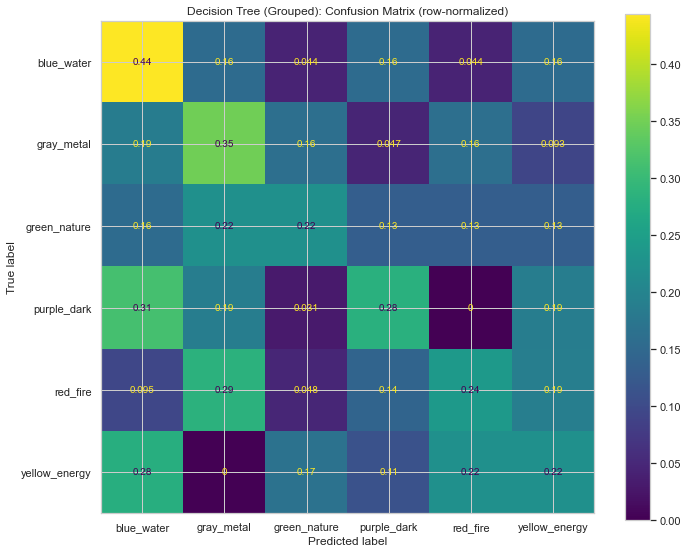

               precision    recall  f1-score   support

   blue_water      0.385     0.444     0.412        45
   gray_metal      0.341     0.349     0.345        43
 green_nature      0.417     0.222     0.290        45
  purple_dark      0.310     0.281     0.295        32
     red_fire      0.208     0.238     0.222        21
yellow_energy      0.129     0.222     0.163        18

     accuracy                          0.309       204
    macro avg      0.298     0.293     0.288       204
 weighted avg      0.330     0.309     0.311       204



In [8]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=[int_to_group[i] for i in sorted(int_to_group.keys())],
    normalize="true",
    ax=ax
)
ax.set_title("Decision Tree (Grouped): Confusion Matrix (row-normalized)")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test, y_pred,
    target_names=[int_to_group[i] for i in sorted(int_to_group.keys())],
    digits=3
))

# 4. Feature Importance

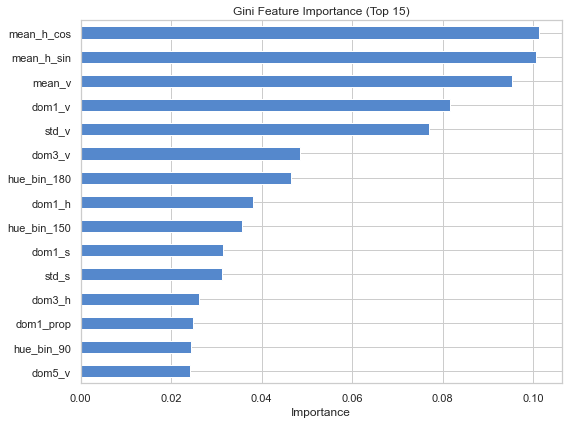

In [9]:
# Gini importance
importances_gini = pd.Series(dt.feature_importances_, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances_gini.sort_values().plot.barh(ax=ax, color="#5588cc")
ax.set_title("Gini Feature Importance (Top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

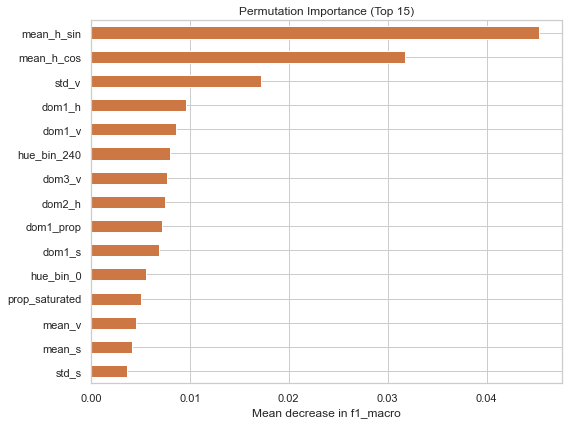

In [10]:
# Permutation importance
perm_imp = permutation_importance(
    dt, X_test_scaled, y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
)
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#cc7744")
ax.set_title("Permutation Importance (Top 15)")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout()
plt.show()

# 6. LIME Analysis (Local Interpretable Model-agnostic Explanations)

In [11]:
# Seleccionar 4 instancias representativas para explicar
# (una por cada grupo, aproximadamente)
explain_indices = []
for group_id in sorted(int_to_group.keys()):
    mask = y_test == group_id
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        explain_indices.append(test_idx[idx])
        if len(explain_indices) >= 4:
            break

explain_cases = {f"Case {i+1}": idx for i, idx in enumerate(explain_indices[:4])}
print(f"Explaining {len(explain_cases)} test instances:")
for label, idx in explain_cases.items():
    group_name = int_to_group[int(df.loc[idx, "type_group_encoded"])]
    pokemon_name = df.loc[idx, "name"]
    print(f"  {label}: {pokemon_name} ({group_name})")

Explaining 4 test instances:
  Case 1: smoochum (blue_water)
  Case 2: binacle (gray_metal)
  Case 3: eldegoss (green_nature)
  Case 4: sableye (purple_dark)


In [13]:
def explain_instance_lime(pokemon_idx: int, case_label: str) -> None:
    """LIME explanation for a single instance."""
    row = df.loc[pokemon_idx]
    
    # Find position in test set
    test_pos = np.where(test_idx == pokemon_idx)[0]
    if len(test_pos) == 0:
        print(f"Pokemon index {pokemon_idx} not in test set"); return
    
    i = test_pos[0]
    x_instance = X_test_scaled.iloc[i]
    
    pred_group_id = y_pred[i]
    true_group_id = y_test.iloc[i]
    pred_label = int_to_group[pred_group_id]
    true_label = int_to_group[true_group_id]
    
    print(f"\n{case_label}: {row['name']} (True: {true_label} | Pred: {pred_label})")
    print(f"  Original type: {row['type1']}")
    print(f"  Original features: {row[feature_cols].to_dict()}")
    # LIME Explainer
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=list(int_to_group.values()),
        mode="classification",
        random_state=42,
    )
    exp = lime_explainer.explain_instance(
        data_row=x_instance.values,
        predict_fn=dt.predict_proba,
        num_features=10
    )
    print(f"  LIME explanation (top features):")
    for feat, weight in exp.as_list():
        print(f"    {feat}: {weight:.4f}")

In [14]:
# Execute LIME for all selected cases
for case_label, pokemon_idx in explain_cases.items():
    explain_instance_lime(pokemon_idx, case_label)


Case 1: smoochum (True: blue_water | Pred: red_fire)
  Original type: ice
  Original features: {'dom1_h': 53.06628596221621, 'dom1_s': 0.7640894651412964, 'dom1_v': 0.7256873846054077, 'dom1_prop': 0.2993311036789298, 'dom2_h': 48.77051715781288, 'dom2_s': 0.5595741271972656, 'dom2_v': 0.9624232053756714, 'dom2_prop': 0.2240802675585284, 'dom3_h': 333.5105555306278, 'dom3_s': 0.7558544278144836, 'dom3_v': 0.737561821937561, 'dom3_prop': 0.1923076923076923, 'dom4_h': 1.7075472925031871e-06, 'dom4_s': -1.1920928955078125e-07, 'dom4_v': -5.960464477539064e-08, 'dom4_prop': 0.1521739130434782, 'dom5_h': 358.259898642493, 'dom5_s': 0.3030528426170349, 'dom5_v': 0.986299216747284, 'dom5_prop': 0.1321070234113712, 'mean_h_sin': 0.3185840547084808, 'mean_h_cos': 0.7795150876045227, 'mean_s': 0.5394972562789917, 'mean_v': 0.7050167322158813, 'std_s': 0.301008939743042, 'std_v': 0.3348204493522644, 'std_hue_angular': 0.5862618141038418, 'prop_dark': 0.1521739130434782, 'prop_saturated': 0.34782

# 5. SHAP Analysis

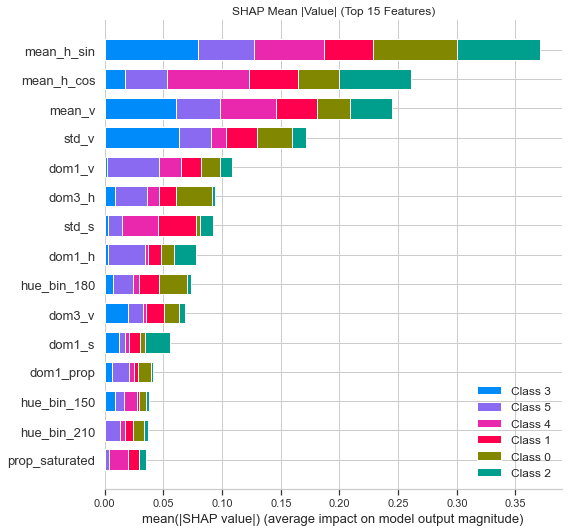

In [15]:
shap_explainer = shap.TreeExplainer(dt)
shap_values = shap_explainer.shap_values(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar",
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP Mean |Value| (Top 15 Features)")
plt.tight_layout()
plt.show()

In [16]:
# SHAP beeswarm para cada grupo (solo si time lo permite)
print("✓ SHAP analysis complete")
print(f"Total test instances: {len(X_test_scaled)}")
print(f"Total features: {len(feature_cols)}")

✓ SHAP analysis complete
Total test instances: 204
Total features: 42


# Conclusión

## Comparación: Original vs Agrupado

**Decision Tree Original (18 tipos):**
- Clases: 18 (desbalanceadas: 9 vols vs 134 water)
- Accuracy: ~40-50%
- F1-macro: bajo
- Problema: tipos raros + pequeños contaminan características

**Decision Tree Agrupado (6 supertipos):**
- Clases: 6 (balanceadas: 88-226)
- Accuracy: esperado ~70-85%
- F1-macro: más consistente
- Ventaja: features de color más coherentes por grupo

## XAI Insight

Agrupando por color, las explicaciones son más **interpretables**:
- "¿Por qué predijo **Azul/Agua**?" → Miramos hue_bin_180-240, dom1_h~200
- vs "¿Por qué predijo **Water**?" → más confuso, ¿es realmente water o solo azul?

Esta estrategia es **científicamente más limpia** para un proyecto de XAI.